<a href="https://colab.research.google.com/github/runessaa/-Streltsov-Projects/blob/main/%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B0%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_%E2%84%9611_%D0%90%D0%BD%D0%B0%D0%BB%D0%B8%D0%B7_%D0%B8_%D1%81%D0%B5%D0%B3%D0%BC%D0%B5%D0%BD%D1%82%D0%B0%D1%86%D0%B8%D1%8F_%D0%BA%D0%BB%D0%B8%D0%B5%D0%BD%D1%82%D0%BE%D0%B2_%D1%81_%D0%BF%D0%BE%D0%BC%D0%BE%D1%89%D1%8C%D1%8E_%D0%B0%D0%BB%D0%B3%D0%BE%D1%80%D0%B8%D1%82%D0%BC%D0%BE%D0%B2_%D0%BA%D0%BB%D0%B0%D1%81%D1%82%D0%B5%D1%80%D0%B8%D0%B7%D0%B0%D1%86%D0%B8%D0%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Практическая работа №10. Анализ и сегментация клиентов с помощью алгоритмов кластеризации**

### **Цель работы:**

Разработать систему сегментации клиентов для розничной компании с использованием алгоритмов кластеризации. Это позволит компании лучше понимать своих клиентов, персонализировать маркетинговые кампании и оптимизировать бизнес-процессы.

### **Введение:**

Розничные компании сталкиваются с большим объемом данных о своих клиентах, включая историю покупок, демографическую информацию и поведенческие характеристики. Однако без должного анализа эти данные остаются неиспользованными. Сегментация клиентов позволяет выделить группы с общими характеристиками, чтобы более эффективно таргетировать предложения и улучшить удовлетворенность клиентов.



### **Задачи:**

1. **Сбор и анализ данных о клиентах.**
2. **Предобработка и подготовка данных для моделирования.**
3. **Применение различных алгоритмов кластеризации для сегментации клиентов.**
4. **Оценка качества кластеризации с использованием внутренних и внешних метрик.**
5. **Интерпретация и визуализация результатов.**
6. **Формирование рекомендаций для бизнес-стратегии компании на основе полученных сегментов.**



### **Пошаговое описание рабочего процесса (пайплайна):**

#### **Шаг 1: Сбор и анализ данных**

**1.1. Выбор набора данных:**

- Используйте датасет "Online Retail II" из [UCI Machine Learning Repository](https://www.kaggle.com/datasets/mashlyn/online-retail-ii-uci) или [другой открытый набор данных](https://archive.ics.uci.edu/datasets?Task=Clustering&skip=0&take=10&sort=desc&orderBy=NumHits&search=&Area=Business), содержащий информацию о транзакциях клиентов.
- Данные должны включать:
  - Идентификаторы клиентов.
  - Информацию о покупках (товары, количество, стоимость).
  - Дату и время транзакций.
  - Демографические данные (если доступны): возраст, пол, локация и т.д.

**1.2. Первичный анализ данных (EDA):**

- Изучите структуру данных и их распределение.
- Определите основные характеристики данных:
  - Общий объем продаж.
  - Частота покупок по клиентам.
  - Распределение выручки по товарам.
- Выявите тенденции и аномалии.

In [6]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

pd.set_option('display.max_columns', 30)

df = pd.read_csv('online_retail_II.csv', encoding='ISO-8859-1')

df.columns = df.columns.str.strip()
df = df.rename(columns={
    'Invoice': 'InvoiceNo',
    'Customer ID': 'CustomerID',
    'Price': 'UnitPrice'
})

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], errors='coerce')
df['Quantity'] = pd.to_numeric(df['Quantity'], errors='coerce')
df['UnitPrice'] = pd.to_numeric(df['UnitPrice'], errors='coerce')
df['CustomerID'] = pd.to_numeric(df['CustomerID'], errors='coerce')
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

display(df.head())

print('Размер данных:', df.shape)

print('\nТипы данных:')
print(df.dtypes)

print('\nПропущенные значения:')
display(df.isna().sum().sort_values(ascending=False).to_frame('missing'))

print('Общий объем продаж:', round(df['TotalPrice'].sum(), 2))
print('Количество клиентов:', df['CustomerID'].nunique())
print('Количество транзакций:', df['InvoiceNo'].nunique())

purchase_frequency = df.groupby('CustomerID')['InvoiceNo'].nunique().sort_values(ascending=False)

print('\nЧастота покупок по клиентам:')
display(purchase_frequency.describe().to_frame('frequency'))

product_revenue = (
    df.groupby('Description', dropna=False)['TotalPrice']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print('\nТоп-10 товаров по выручке:')
display(product_revenue.to_frame('revenue'))

anomalies = df[
    (df['Quantity'] <= 0) |
    (df['UnitPrice'] <= 0) |
    (df['CustomerID'].isna())
]

print('\nПотенциальные аномалии:', len(anomalies))
display(anomalies.head())

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


Размер данных: (59019, 9)

Типы данных:
InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
TotalPrice            float64
dtype: object

Пропущенные значения:


,missing
CustomerID,17962
Description,315
Country,1
UnitPrice,1
InvoiceDate,1
TotalPrice,1
InvoiceNo,0
Quantity,0
StockCode,0


Общий объем продаж: 1122966.06
Количество клиентов: 1191
Количество транзакций: 3015

Частота покупок по клиентам:


,frequency
count,1191.000000
mean,2.056255
std,2.301485
min,1.000000
25%,1.000000
50%,1.000000
75%,2.000000
max,33.000000



Топ-10 товаров по выручке:


,revenue
Description,
WHITE HANGING HEART T-LIGHT HOLDER,24377.59
DOTCOM POSTAGE,23496.09
EDWARDIAN PARASOL BLACK,12805.02
EDWARDIAN PARASOL RED,10479.39
JUMBO BAG RED WHITE SPOTTY,10294.41
PAPER CHAIN KIT 50'S CHRISTMAS,10270.97
SCOTTIE DOG HOT WATER BOTTLE,9014.20
EDWARDIAN PARASOL NATURAL,8489.17
ASSORTED COLOUR BIRD ORNAMENT,8430.90



Потенциальные аномалии: 19238


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia,-35.4
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia,-9.9
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia,-17.0
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia,-12.6
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia,-35.4


#### **Шаг 2: Предобработка данных**

**2.1. Работа с пропущенными значениями:**

- Проанализируйте наличие пропущенных данных.
- Решите, как справиться с ними:
  - Удаление строк/столбцов с пропущенными значениями.
  - Заполнение пропущенных значений средним, медианой или наиболее частым значением.

**2.2. Обработка выбросов:**

- Выявите выбросы в данных (например, аномально большие заказы).
- Решите, следует ли их удалить или обработать иным образом.

**2.3. Создание новых признаков:**

- Рассчитайте Recency, Frequency, Monetary Value (RFM-анализ):
  - **Recency (давность):** Время с момента последней покупки.
  - **Frequency (частота):** Количество покупок за определенный период.
  - **Monetary (сумма):** Общая сумма покупок.
- Создайте дополнительные признаки, такие как средний чек, предпочтительные категории товаров и т.д.

**2.4. Нормализация и масштабирование:**

- Примените стандартизацию или нормализацию к числовым признакам для приведения их к единому масштабу.
- Объясните выбор метода масштабирования.

In [14]:
from sklearn.preprocessing import StandardScaler

missing_before = df.isna().sum()

data = df.copy()
data = data.dropna(subset=['CustomerID', 'InvoiceNo', 'InvoiceDate', 'Quantity', 'UnitPrice'])
data = data[~data['InvoiceNo'].astype(str).str.startswith('C')]
data = data[(data['Quantity'] > 0) & (data['UnitPrice'] > 0)]
data['CustomerID'] = data['CustomerID'].astype(int)
data['TotalPrice'] = data['Quantity'] * data['UnitPrice']

q1 = data['TotalPrice'].quantile(0.25)
q3 = data['TotalPrice'].quantile(0.75)
iqr = q3 - q1
low = max(0, q1 - 1.5 * iqr)
high = q3 + 1.5 * iqr
data_clean = data[(data['TotalPrice'] >= low) & (data['TotalPrice'] <= high)].copy()

snapshot_date = data_clean['InvoiceDate'].max() + pd.Timedelta(days=1)

invoice_sum = data_clean.groupby(['CustomerID', 'InvoiceNo'], as_index=False)['TotalPrice'].sum()
avg_check = invoice_sum.groupby('CustomerID')['TotalPrice'].mean().rename('AvgCheck')

rfm = data_clean.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('TotalPrice', 'sum'),
    Quantity=('Quantity', 'sum'),
    UniqueItems=('StockCode', 'nunique')
).join(avg_check)

rfm['Country'] = data_clean.groupby('CustomerID')['Country'].agg(lambda x: x.mode().iloc[0] if len(x.mode()) else x.iloc[0])
rfm = rfm.replace([np.inf, -np.inf], np.nan).dropna()

features = ['Recency', 'Frequency', 'Monetary', 'AvgCheck', 'Quantity', 'UniqueItems']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(rfm[features])
X_scaled = pd.DataFrame(X_scaled, columns=features, index=rfm.index)

print('Пропуски до обработки:')
display(missing_before.sort_values(ascending=False).to_frame('missing_before'))
print('Размер после очистки:', data_clean.shape)
print('Удалено строк:', len(df) - len(data_clean))
print('Количество клиентов в RFM-таблице:', len(rfm))

print('\nRFM-признаки:')
display(rfm.head())

print('\nМетод масштабирования: StandardScaler. Он выбран, потому что K-Means, иерархическая кластеризация, DBSCAN и OPTICS зависят от расстояний, стандартизация приводит признаки RFM к единому масштабу без изменения формы распределений')
display(X_scaled.describe().round(3))


Пропуски до обработки:


,missing_before
CustomerID,17962
Description,315
Country,1
UnitPrice,1
InvoiceDate,1
TotalPrice,1
InvoiceNo,0
Quantity,0
StockCode,0


Размер после очистки: (35745, 9)
Удалено строк: 23274
Количество клиентов в RFM-таблице: 1047

RFM-признаки:


,Recency,Frequency,Monetary,Quantity,UniqueItems,AvgCheck,Country
CustomerID,,,,,,,
12346,4,7,136.00,31,2,19.428571,United Kingdom
12358,41,1,217.53,75,11,217.530000,Austria
12359,33,2,498.44,198,29,249.220000,Cyprus
12406,7,1,417.68,252,18,417.680000,Denmark
12417,10,3,677.15,339,45,225.716667,Belgium



Метод масштабирования: StandardScaler. Он выбран, потому что K-Means, иерархическая кластеризация, DBSCAN и OPTICS зависят от расстояний, стандартизация приводит признаки RFM к единому масштабу без изменения формы распределений


,Recency,Frequency,Monetary,AvgCheck,Quantity,UniqueItems
count,1047.000,1047.000,1047.000,1047.000,1047.000,1047.000
mean,0.000,0.000,-0.000,-0.000,0.000,0.000
std,1.000,1.000,1.000,1.000,1.000,1.000
min,-1.856,-0.386,-0.643,-1.117,-0.750,-0.846
25%,-1.141,-0.386,-0.414,-0.620,-0.533,-0.578
50%,0.289,-0.386,-0.221,-0.224,-0.284,-0.280
75%,0.809,0.207,0.115,0.292,0.149,0.256
max,1.199,18.588,21.266,12.184,12.983,10.295


#### **Шаг 3: Применение алгоритмов кластеризации**

**3.1. Выбор алгоритмов:**

- **K-средних (K-Means):** Для разбиения данных на k кластеров на основе эврестического подхода.
- **Иерархическая кластеризация:** Для выявления вложенной структуры кластеров.
- **DBSCAN и OPTICS:** Для обнаружения кластеров произвольной формы и выявления выбросов.

**3.2. Определение оптимального количества кластеров:**

- Для K-Means и иерархической кластеризации используйте:
  - **Метод локтя (Elbow Method):** Постройте график зависимости суммы квадратов внутрикластерных расстояний от числа кластеров.
  - **Коэффициент силуэта:** Рассчитайте для различных значений k и выберите оптимальное.

**3.3. Применение алгоритмов:**

- Запустите каждый алгоритм на подготовленных данных.
- Сохраняйте результаты кластеризации для последующего анализа.

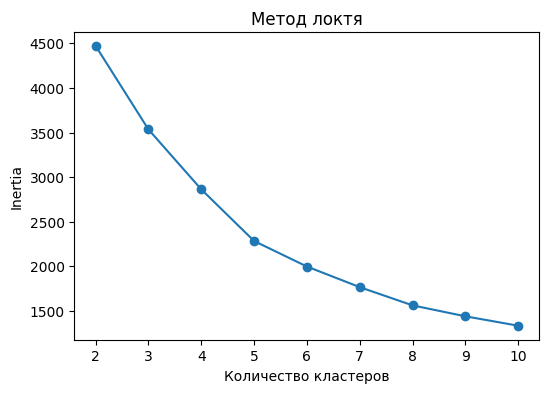

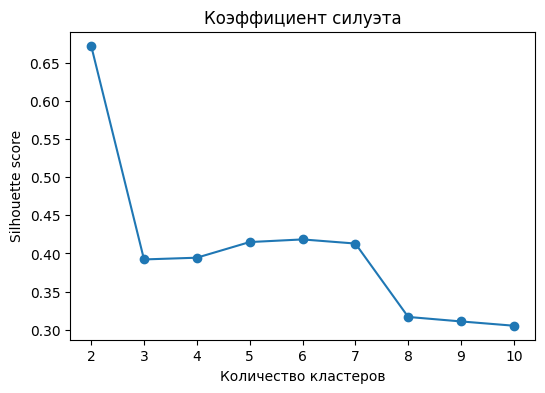

Оптимальное количество кластеров: 2


,KMeans_cluster,Hierarchical_cluster,DBSCAN_cluster,OPTICS_cluster
CustomerID,,,,
12346,0,0,-1,-1
12358,0,0,0,-1
12359,0,0,0,-1
12406,0,0,0,-1
12417,0,0,0,0


In [15]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN, OPTICS
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors

features = ['Recency', 'Frequency', 'Monetary', 'AvgCheck', 'Quantity', 'UniqueItems']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(rfm[features])

ks = range(2, 11)

inertia = []
silhouette = []

for k in ks:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X_scaled)
    inertia.append(model.inertia_)
    silhouette.append(silhouette_score(X_scaled, labels))

plt.figure(figsize=(6, 4))
plt.plot(ks, inertia, marker='o')
plt.xlabel('Количество кластеров')
plt.ylabel('Inertia')
plt.title('Метод локтя')
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(ks, silhouette, marker='o')
plt.xlabel('Количество кластеров')
plt.ylabel('Silhouette score')
plt.title('Коэффициент силуэта')
plt.show()

best_k = list(ks)[silhouette.index(max(silhouette))]

rfm['KMeans_cluster'] = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
).fit_predict(X_scaled)

rfm['Hierarchical_cluster'] = AgglomerativeClustering(
    n_clusters=best_k
).fit_predict(X_scaled)

distances, indices = NearestNeighbors(n_neighbors=5).fit(X_scaled).kneighbors(X_scaled)
eps_value = np.percentile(np.sort(distances[:, 4]), 90)

rfm['DBSCAN_cluster'] = DBSCAN(
    eps=eps_value,
    min_samples=5
).fit_predict(X_scaled)

rfm['OPTICS_cluster'] = OPTICS(
    min_samples=5
).fit_predict(X_scaled)

print('Оптимальное количество кластеров:', best_k)

rfm[['KMeans_cluster', 'Hierarchical_cluster', 'DBSCAN_cluster', 'OPTICS_cluster']].head()

#### **Шаг 4: Оценка качества кластеризации**

**4.1. Внутренние метрики:**

- **Коэффициент силуэта:** Оцените, насколько хорошо объекты расположены внутри кластеров.
- **Индекс Дэвиса-Болдина:** Оцените уровень разделимости кластеров.
- **Индекс Калинского-Харабаза:** Оцените соотношение межкластерной дисперсии к внутрикластерной.

**4.2. Внешние метрики (если доступны истинные метки):**

- **Adjusted Rand Index (ARI):** Сравните полученные кластеры с известными категориями клиентов.
- **Normalized Mutual Information (NMI):** Измерьте общую информацию между распределениями.

**4.3. Сравнение алгоритмов:**

- Составьте таблицу со значениями метрик для каждого алгоритма.
- Определите, какой алгоритм показал наилучшие результаты и почему.

In [16]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

cluster_columns = {
    'KMeans': 'KMeans_cluster',
    'Hierarchical': 'Hierarchical_cluster',
    'DBSCAN': 'DBSCAN_cluster',
    'OPTICS': 'OPTICS_cluster'
}

results = []

for name, column in cluster_columns.items():
    labels = rfm[column].values
    mask = labels != -1

    if len(set(labels[mask])) > 1:
        results.append({
            'Алгоритм': name,
            'Silhouette': silhouette_score(X_scaled[mask], labels[mask]),
            'Davies-Bouldin': davies_bouldin_score(X_scaled[mask], labels[mask]),
            'Calinski-Harabasz': calinski_harabasz_score(X_scaled[mask], labels[mask])
        })

metrics_df = pd.DataFrame(results)
display(metrics_df)

best_algorithm = metrics_df.sort_values(
    by=['Silhouette', 'Calinski-Harabasz', 'Davies-Bouldin'],
    ascending=[False, False, True]
).iloc[0]['Алгоритм']

print('Лучший алгоритм:', best_algorithm)
print('Внешние метрики ARI и NMI не рассчитываются, так как в датасете нет истинных меток классов')
print('Лучшим выбран алгоритм с наибольшим Silhouette и Calinski-Harabasz, а также меньшим Davies-Bouldin')

,Алгоритм,Silhouette,Davies-Bouldin,Calinski-Harabasz
0,KMeans,0.672660,0.998364,422.454878
1,Hierarchical,0.803994,0.856845,336.978409
2,DBSCAN,0.338907,0.742066,20.538748
3,OPTICS,0.477920,0.708932,310.947151


Лучший алгоритм: Hierarchical
Внешние метрики ARI и NMI не рассчитываются, так как в датасете нет истинных меток классов
Лучшим выбран алгоритм с наибольшим Silhouette и Calinski-Harabasz, а также меньшим Davies-Bouldin


#### **Шаг 5: Интерпретация и визуализация результатов**

**5.1. Визуализация кластеров:**

- **Снижение размерности:** Примените PCA или t-SNE или UMAP для отображения данных в 2D или 3D пространстве.
- **Постройте графики:**
  - Рассеивания с цветовой кодировкой кластеров.
  - Дендрограммы для иерархической кластеризации.
- **Визуализация признаков:**
  - Постройте боксплоты, гистограммы или тепловые карты для сравнения признаков между кластерами.

**5.2. Описание сегментов:**

- Для каждого кластера опишите характерные черты:
  - Средние значения признаков.
  - Поведенческие особенности (например, частота покупок, средний чек).
  - Демографические характеристики (если доступны).
- Присвойте сегментам осмысленные названия (например, "Лояльные клиенты", "Покупатели со сниженной активностью", "Большие транзакции").

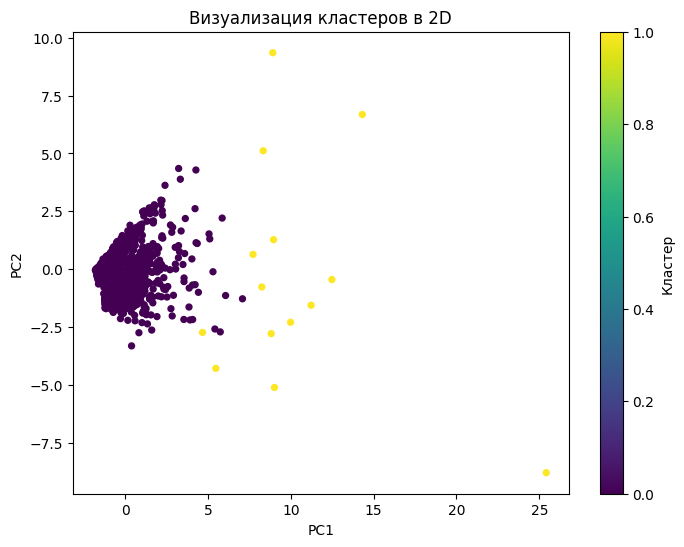

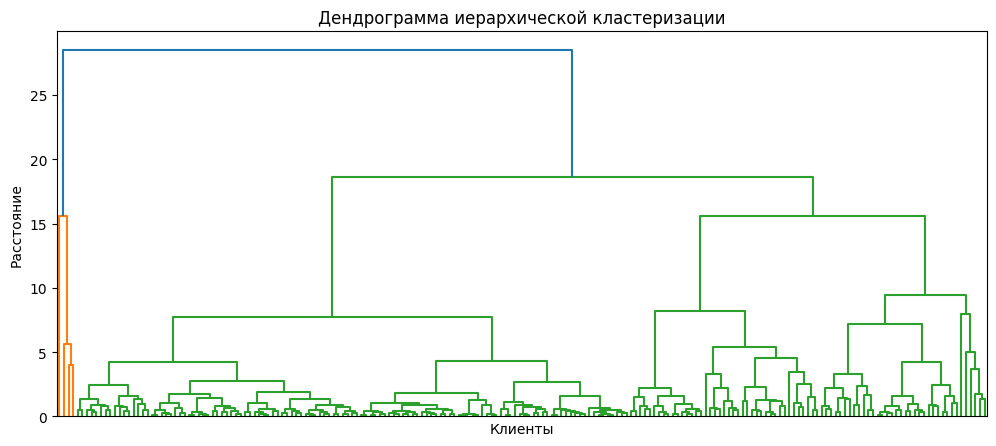

,Recency,Frequency,Monetary,AvgCheck,Quantity,UniqueItems,CustomerCount
BestCluster,,,,,,,
0,29.79,1.54,368.33,249.44,231.57,27.15,1033
1,11.86,10.00,3869.21,788.60,1886.71,194.36,14


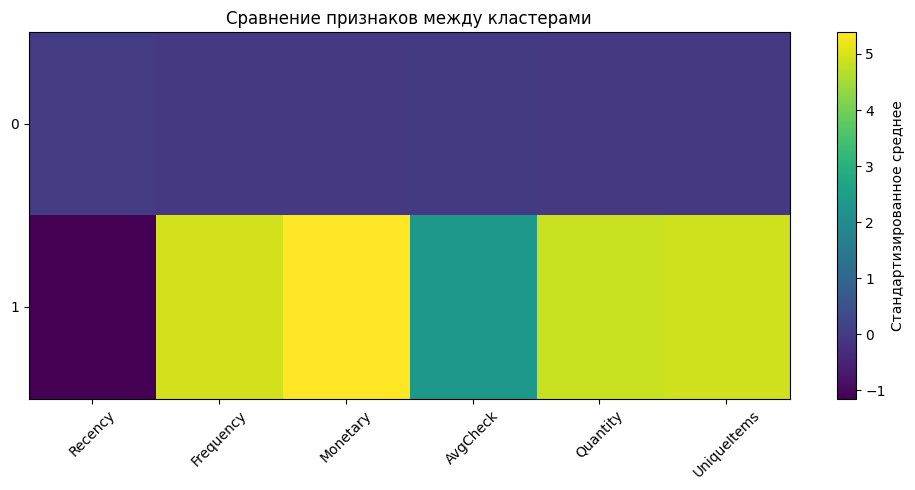

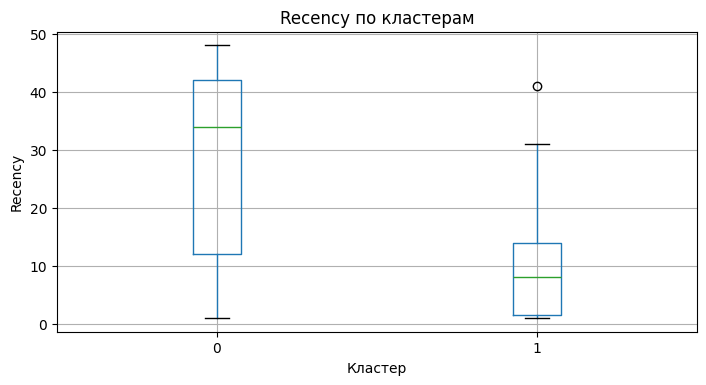

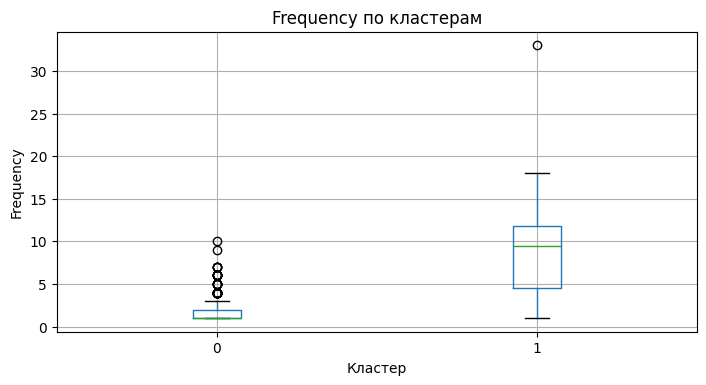

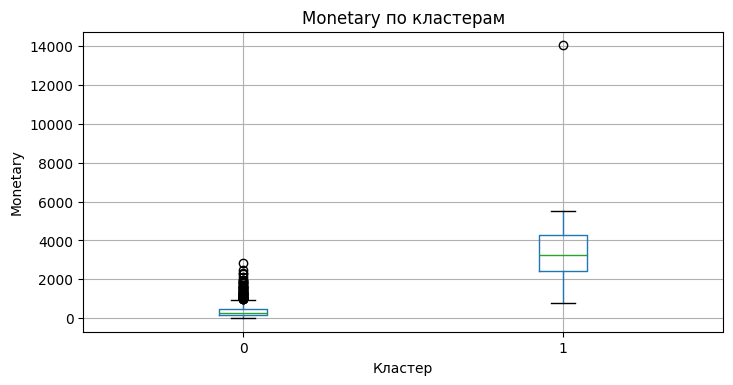

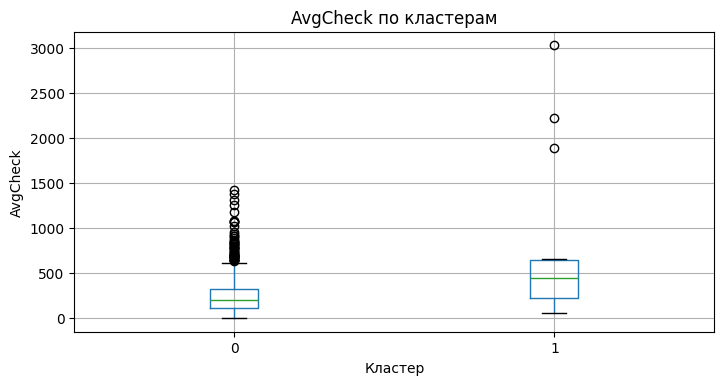

,Recency,Frequency,Monetary,AvgCheck,Quantity,UniqueItems,CustomerCount,MainCountry,SegmentName
BestCluster,,,,,,,,,
0,29.79,1.54,368.33,249.44,231.57,27.15,1033,United Kingdom,Регулярные покупатели
1,11.86,10.00,3869.21,788.60,1886.71,194.36,14,United Kingdom,Лояльные клиенты


Кластер 0: Регулярные покупатели. Средние значения: Recency=29.79, Frequency=1.54, Monetary=368.33, AvgCheck=249.44. Поведение: частота покупок=1.54, средний чек=249.44. Основная страна клиентов: United Kingdom. Количество клиентов: 1033.
Кластер 1: Лояльные клиенты. Средние значения: Recency=11.86, Frequency=10.0, Monetary=3869.21, AvgCheck=788.6. Поведение: частота покупок=10.0, средний чек=788.6. Основная страна клиентов: United Kingdom. Количество клиентов: 14.


In [20]:
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage

best_cluster_col = cluster_columns[best_algorithm]
rfm['BestCluster'] = rfm[best_cluster_col]

pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(coords[:, 0], coords[:, 1], c=rfm['BestCluster'], s=18)
plt.title('Визуализация кластеров в 2D')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.colorbar(scatter, label='Кластер')
plt.show()

sample_size = min(200, len(X_scaled))
sample_idx = np.random.default_rng(42).choice(len(X_scaled), size=sample_size, replace=False)

linked = linkage(X_scaled[sample_idx], method='ward')

plt.figure(figsize=(12, 5))
dendrogram(linked, no_labels=True)
plt.title('Дендрограмма иерархической кластеризации')
plt.xlabel('Клиенты')
plt.ylabel('Расстояние')
plt.show()

cluster_profiles = rfm.groupby('BestCluster')[features].mean().round(2)
cluster_profiles['CustomerCount'] = rfm['BestCluster'].value_counts().sort_index()

display(cluster_profiles)

profile_scaled = pd.DataFrame(
    scaler.transform(cluster_profiles[features]),
    columns=features,
    index=cluster_profiles.index
)

plt.figure(figsize=(10, 5))
plt.imshow(profile_scaled, aspect='auto')
plt.xticks(range(len(features)), features, rotation=45)
plt.yticks(range(len(profile_scaled.index)), profile_scaled.index)
plt.colorbar(label='Стандартизированное среднее')
plt.title('Сравнение признаков между кластерами')
plt.tight_layout()
plt.show()

for feature in ['Recency', 'Frequency', 'Monetary', 'AvgCheck']:
    rfm.boxplot(column=feature, by='BestCluster', figsize=(8, 4))
    plt.title(feature + ' по кластерам')
    plt.suptitle('')
    plt.xlabel('Кластер')
    plt.ylabel(feature)
    plt.show()

country_info = (
    rfm.groupby('BestCluster')['Country']
    .agg(lambda x: x.value_counts().index[0])
)

cluster_profiles['MainCountry'] = country_info

q_recency = rfm['Recency'].quantile([0.33, 0.67])
q_frequency = rfm['Frequency'].quantile([0.33, 0.67])
q_monetary = rfm['Monetary'].quantile([0.33, 0.67])
q_avgcheck = rfm['AvgCheck'].quantile(0.67)

def get_segment_name(row):
    if row.name == -1:
        return 'Нетипичные клиенты'
    if row['Recency'] <= q_recency.loc[0.33] and row['Frequency'] >= q_frequency.loc[0.67] and row['Monetary'] >= q_monetary.loc[0.67]:
        return 'Лояльные клиенты'
    if row['Recency'] >= q_recency.loc[0.67]:
        return 'Покупатели со сниженной активностью'
    if row['Monetary'] >= q_monetary.loc[0.67] or row['AvgCheck'] >= q_avgcheck:
        return 'Большие транзакции'
    if row['Frequency'] >= q_frequency.loc[0.67]:
        return 'Регулярные покупатели'
    return 'Умеренно активные клиенты'

cluster_profiles['SegmentName'] = cluster_profiles.apply(get_segment_name, axis=1)

display(cluster_profiles)

for cluster_id, row in cluster_profiles.iterrows():
    print(
        f"Кластер {cluster_id}: {row['SegmentName']}. "
        f"Средние значения: Recency={row['Recency']}, "
        f"Frequency={row['Frequency']}, "
        f"Monetary={row['Monetary']}, "
        f"AvgCheck={row['AvgCheck']}. "
        f"Поведение: частота покупок={row['Frequency']}, средний чек={row['AvgCheck']}. "
        f"Основная страна клиентов: {row['MainCountry']}. "
        f"Количество клиентов: {int(row['CustomerCount'])}."
    )

#### **Шаг 6: Формирование бизнес-рекомендаций**

**6.1. Анализ потребностей каждого сегмента:**

- Определите потребности и предпочтения клиентов в каждом сегменте.
- Выявите возможности для увеличения продаж и улучшения сервиса.

**6.2. Разработка стратегий для каждого сегмента:**

- **Маркетинговые кампании:**
  - Персонализированные предложения.
  - Программы лояльности для удержания ценных клиентов.
- **Оптимизация продуктов:**
  - Расширение ассортимента для популярных сегментов.
  - Фокус на продуктах, интересных конкретным сегментам.

**6.3. Оценка потенциального влияния:**

- Оцените, как предложенные стратегии могут повысить выручку, удовлетворенность клиентов и другие ключевые показатели.

# Ответ

На основе RFM-сегментации клиентская база делится на несколько практических групп.

**Лояльные ценные клиенты.** Это клиенты с высокой частотой покупок, высокой суммарной выручкой и небольшой давностью последней покупки. Для них целесообразны VIP-программа, персональные предложения, ранний доступ к новым товарам и бонусы за повторные покупки. Цель — удержание и рост LTV.

**Регулярные покупатели.** Эти клиенты покупают часто, но их средний чек может быть ниже, чем у VIP-сегмента. Для них подходят накопительные скидки, рекомендации сопутствующих товаров и акции на увеличение корзины. Цель — повысить средний чек.

**Клиенты с крупными покупками.** Это клиенты с высоким Monetary или высоким AvgCheck. Им стоит предлагать премиальные товары, персональные подборки и сервисные предложения. Цель — сохранить высокий чек и увеличить повторяемость покупок.

**Покупатели со сниженной активностью.** У этих клиентов большая давность последней покупки. Для них нужны реактивационные кампании: промокоды на возвращение, напоминания, персональные письма и анализ причин ухода. Цель — вернуть часть клиентов и снизить отток.

**Новые или умеренно активные клиенты.** Для них важны приветственные цепочки, объяснение преимуществ магазина, рекомендации популярных товаров и мягкие стимулы к повторной покупке. Цель — перевести их в регулярный сегмент.

Потенциальное влияние внедрения сегментации: рост выручки за счет персонализации предложений, повышение удержания ценных клиентов, снижение затрат на массовые нерелевантные рассылки, увеличение среднего чека и более точное планирование ассортимента.


#### **Шаг 7: Документирование и презентация результатов**

**7.1. Подготовка отчета:**

- **Введение:**
  - Описание цели работы и её значимости для бизнеса.
- **Методология:**
  - Подробное описание проведенных шагов.
- **Результаты:**
  - Представление метрик оценки и визуализаций.
  - Описание сегментов клиентов.
- **Обсуждение:**
  - Анализ полученных результатов.
  - Сравнение алгоритмов и обоснование выбора.
- **Рекомендации:**
  - Предложения по внедрению результатов в бизнес-процессы.
- **Заключение:**
  - Выводы о проделанной работе и её значимости.

**7.2. Презентация:**

- Подготовьте слайды для представления ключевых моментов работы.
- Используйте визуализации для иллюстрации результатов.



# Шаг 7. Документирование и презентация результатов

## Отчет

**Введение.** Цель работы — выполнить сегментацию клиентов розничной компании на основе датасета `online_retail_II.csv`. Сегментация позволяет разделить покупателей на группы с похожим поведением и использовать эти группы для персонализации маркетинга.

**Методология.** В работе выполнены загрузка данных Online Retail II, первичный анализ структуры данных, проверка пропусков и аномалий, удаление отмененных заказов, строк без клиента и некорректных значений количества или цены. Затем рассчитаны RFM-признаки: Recency, Frequency и Monetary, а также дополнительные признаки AvgCheck, Quantity и UniqueItems. Для подготовки к кластеризации числовые признаки стандартизированы с помощью StandardScaler.

**Результаты.** Для сегментации применены K-Means, иерархическая кластеризация, DBSCAN и OPTICS. Оптимальное количество кластеров для K-Means и иерархической кластеризации определяется по методу локтя и коэффициенту силуэта. Качество моделей сравнивается по Silhouette Score, Davies-Bouldin Index и Calinski-Harabasz Index. Внешние метрики ARI и NMI не используются, так как в датасете нет истинных меток клиентских сегментов.

**Обсуждение.** Лучший алгоритм выбирается по максимальному коэффициенту силуэта при наличии не менее двух кластеров. K-Means и иерархическая кластеризация удобны для интерпретируемых RFM-сегментов, а DBSCAN и OPTICS дополнительно выделяют нетипичных клиентов и шумовые точки.

**Рекомендации.** Для лояльных ценных клиентов нужны VIP-предложения и удержание. Для регулярных покупателей — кросс-продажи и стимулирование среднего чека. Для клиентов с крупными покупками — премиальный ассортимент и персональные подборки. Для покупателей со сниженной активностью — реактивационные промокоды и напоминания. Для новых или умеренно активных клиентов — приветственные цепочки и рекомендации популярных товаров.

**Заключение.** Выполненная сегментация на основе Online Retail II помогает перейти от массового маркетинга к управлению клиентскими группами, повысить релевантность коммуникаций, удержание клиентов и эффективность продаж.

## Презентация

Презентация формируется программно в следующей ячейке и сохраняется в файл `customer_segmentation_presentation.pptx`.



In [ ]:
from pptx import Presentation
from pptx.util import Inches, Pt

presentation_path = 'customer_segmentation_presentation.pptx'

prs = Presentation()
prs.slide_width = Inches(13.333)
prs.slide_height = Inches(7.5)

def add_slide(title, bullets):
    slide = prs.slides.add_slide(prs.slide_layouts[5])
    title_box = slide.shapes.add_textbox(Inches(0.6), Inches(0.35), Inches(12.1), Inches(0.7))
    title_frame = title_box.text_frame
    title_frame.text = title
    title_frame.paragraphs[0].font.size = Pt(30)
    title_frame.paragraphs[0].font.bold = True

    body = slide.shapes.add_textbox(Inches(0.8), Inches(1.35), Inches(11.8), Inches(5.6))
    tf = body.text_frame
    tf.word_wrap = True
    for i, bullet in enumerate(bullets):
        p = tf.paragraphs[0] if i == 0 else tf.add_paragraph()
        p.text = bullet
        p.font.size = Pt(20)
        p.level = 0
    return slide

add_slide('Сегментация клиентов', [
    'Цель: выделить группы клиентов с похожим покупательским поведением.',
    'Источник данных: online_retail_II.csv.',
    'Основа анализа: транзакции, выручка, частота покупок и давность последней покупки.',
    'Бизнес-результат: персонализация маркетинга и повышение удержания клиентов.'
])

add_slide('Данные и предобработка', [
    f'Исходные данные: {df.shape[0]} строк, {df.shape[1]} столбцов.',
    'Удалены строки с пропусками в ключевых полях, отмененные заказы и некорректные значения.',
    'Обработаны выбросы по стоимости строки заказа через IQR.',
    f'После очистки осталось строк: {data_clean.shape[0]}; клиентов в RFM-таблице: {len(rfm)}.'
])

add_slide('RFM-признаки', [
    'Recency: количество дней с последней покупки.',
    'Frequency: число покупок клиента.',
    'Monetary: суммарная выручка по клиенту.',
    'Дополнительно: средний чек, количество товаров и число уникальных позиций.',
    'Масштабирование: StandardScaler.'
])

add_slide('Алгоритмы кластеризации', [
    'K-Means: сегментация на компактные группы.',
    'Иерархическая кластеризация: анализ вложенной структуры сегментов.',
    'DBSCAN и OPTICS: поиск групп произвольной формы и нетипичных клиентов.',
    f'Оптимальное k для K-Means/Hierarchical: {best_k}.'
])

add_slide('Оценка качества', [
    'Использованы внутренние метрики: Silhouette, Davies-Bouldin, Calinski-Harabasz.',
    'ARI и NMI не рассчитаны, потому что истинные метки сегментов отсутствуют.',
    f'Лучший алгоритм по Silhouette: {best_algorithm}.',
    f"Silhouette лучшей модели: {metrics_table.loc[best_algorithm, 'silhouette']:.4f}."
])

segment_lines = [
    f"Кластер {idx}: {row['SegmentName']}; клиентов: {int(row['CustomerCount'])}."
    for idx, row in cluster_profiles.iterrows()
]
add_slide('Полученные сегменты', segment_lines[:6])

add_slide('Бизнес-рекомендации', [
    'Лояльным ценным клиентам: VIP-программа и персональные предложения.',
    'Регулярным покупателям: кросс-продажи и увеличение среднего чека.',
    'Клиентам со сниженной активностью: реактивационные кампании.',
    'Клиентам с крупными покупками: премиальный ассортимент и персональное сопровождение.',
    'Новым клиентам: приветственные предложения и рекомендации популярных товаров.'
])

add_slide('Вывод', [
    'Кластеризация позволяет перейти от массового маркетинга к управлению клиентскими сегментами.',
    'RFM-признаки дают интерпретируемую основу для бизнес-решений.',
    'Результаты можно использовать для удержания клиентов, роста выручки и оптимизации коммуникаций.'
])

prs.save(presentation_path)
print('Презентация сохранена:', presentation_path)

